In [1]:
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
import os
import math
import cmaps # type: ignore
import cartopy.crs as ccrs  # type: ignore
import cartopy.feature as cfeature  # type: ignore


def plot_2d_variable(
    variable,
    cmap=cmaps.WhiteBlueGreenYellowRed,
    figsize=(6, 5),
    lat_ascending=True,
    lon_ascending=True,
    dpi=150,
    colorbar_range=None,  
    nan_color="white", 
    replace_nan_with=None, 
):

    if variable.ndim != 2:
        raise ValueError("The input variable must be a 2D array with shape (H, W).")

    if replace_nan_with is not None:
        variable = np.nan_to_num(variable, nan=replace_nan_with)

    if lat_ascending:
        variable = np.flipud(variable)  # If the latitude goes from small to large, it is flipped vertically
    if not lon_ascending:
        variable = np.fliplr(variable)  # If the longitude is from large to small, it is flipped horizontally

    cmap = plt.cm.get_cmap(cmap).copy()
    cmap.set_bad(color=nan_color) 

    plt.figure(figsize=figsize, dpi=dpi)
    img = plt.imshow(
        variable,
        cmap=cmap,
        aspect="auto",
        vmin=colorbar_range[0] if colorbar_range else None,
        vmax=colorbar_range[1] if colorbar_range else None,
    )
    plt.colorbar(img)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")

    plt.show()


In [2]:
import os
import numpy as np  # type: ignore

def extract_subregion(filename, lat_start_idx, lat_end_idx, lon_start_idx, lon_end_idx):
    """
    Extract a subregion from the data file based on specified index ranges.

    Args:
        filename (str): Path to the data file.
        lat_start_idx (int): Start index for the latitude dimension.
        lat_end_idx (int): End index for the latitude dimension.
        lon_start_idx (int): Start index for the longitude dimension.
        lon_end_idx (int): End index for the longitude dimension.

    Returns:
        subregion_channel1 (np.ndarray): Extracted subregion from channel 1.
        subregion_channel2 (np.ndarray): Extracted subregion from channel 2.
    """
    # Read binary file content
    with open(filename, 'rb') as f:
        data = np.fromfile(f, dtype=np.float32)

    data = np.reshape(data, (2, 440, 700))
    channel1, channel2 = data[0], data[1]

    # Extract the subregion
    subregion_channel1 = channel1[lat_start_idx:lat_end_idx+1, lon_start_idx:lon_end_idx+1]
    subregion_channel2 = channel2[lat_start_idx:lat_end_idx+1, lon_start_idx:lon_end_idx+1]

    return subregion_channel1, subregion_channel2

In [3]:
channel1, channel2 = extract_subregion(f"SURF_CLI_CHN_MERGE_CMP_PRE_HOUR_GRID_0.10-2016080316.grd", 49, 298, 300, 549)

In [4]:
channel1.shape

(250, 250)

In [5]:
channel1.max()

np.float32(38.91377)

/var/folders/8t/zkys77v97lggg4gsf31n6j540000gn/T/ipykernel_3057/3024216500.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap).copy()


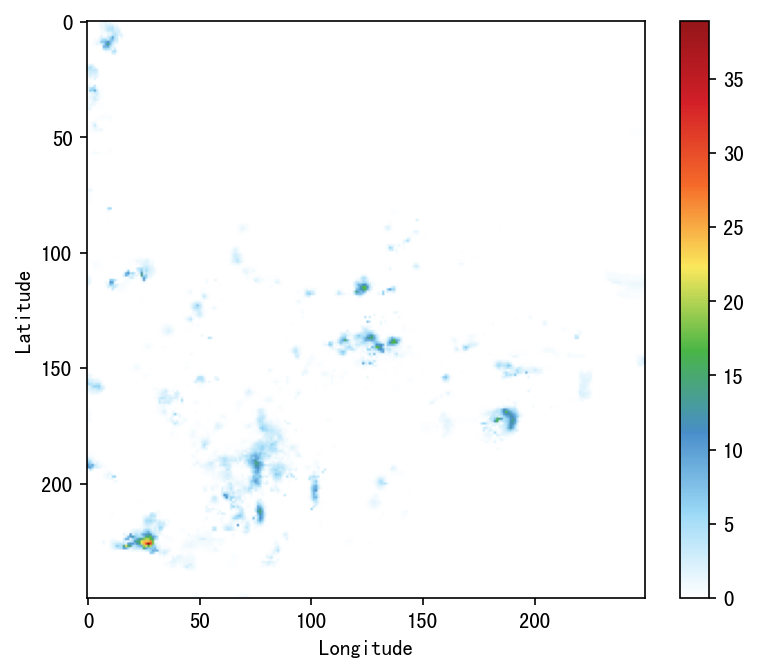

In [6]:
plot_2d_variable(channel1)

/var/folders/8t/zkys77v97lggg4gsf31n6j540000gn/T/ipykernel_3057/3024216500.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap).copy()


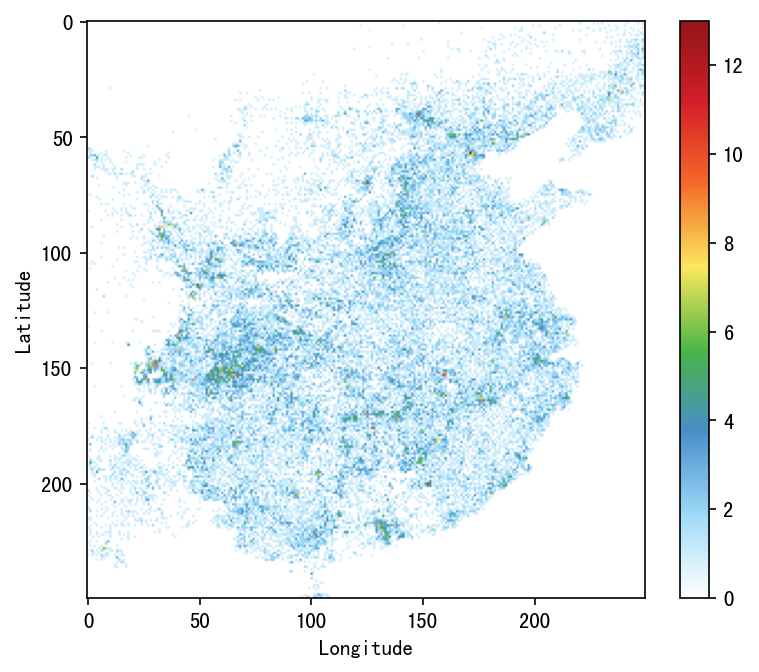

In [7]:
plot_2d_variable(channel2)

In [8]:
channel2.min()

np.float32(0.0)

In [9]:
channel2.max()

np.float32(13.0)

In [10]:
matrix = channel2[:, :]
mask = matrix >= 4
count = np.sum(mask)

print(f"Number of grid points with values ≥ 4: {count}")
print(f"Proportion of grid points with values ≥ 4: {count *100 / matrix.size:.4f} %")

Number of grid points with values ≥ 4: 937
Proportion of grid points with values ≥ 4: 1.4992 %


In [11]:
mask

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(250, 250))

In [13]:
matrix = channel2[:, :]
mask = matrix >= 1
count = np.sum(mask)

print(f"Number of grid points with values ≥ 1: {count}")
print(f"Proportion of grid points with values ≥ 1: {count *100 / matrix.size:.4f} %")

Number of grid points with values ≥ 1: 21630
Proportion of grid points with values ≥ 1: 34.6080 %
